# **EDA**

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [4]:
df = pd.read_csv("/content/train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
df.shape

(1460, 81)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
kolom_numerik = df.select_dtypes(include=[np.number]).columns.tolist()

kolom_kategorik = (df.select_dtypes(exclude=[np.number]).columns.tolist())

df[kolom_numerik].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.50,421.61,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.90,42.30,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.05,24.28,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.83,9981.26,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.10,1.38,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.58,1.11,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.27,30.20,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.87,20.65,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.69,181.07,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.64,456.10,0.0,0.00,383.5,712.25,5644.0


In [8]:
df[kolom_kategorik].describe().T

,count,unique,top,freq
MSZoning,1460,5,RL,1151
Street,1460,2,Pave,1454
Alley,91,2,Grvl,50
LotShape,1460,4,Reg,925
LandContour,1460,4,Lvl,1311
Utilities,1460,2,AllPub,1459
LotConfig,1460,5,Inside,1052
LandSlope,1460,3,Gtl,1382
Neighborhood,1460,25,NAmes,225
Condition1,1460,9,Norm,1260


# **Pembersihan Data**

In [9]:
ringkas_missing = pd.DataFrame({
    "jumlah_kosong": df.isna().sum(),
    "persen_kosong": (df.isna().mean() * 100).round(2),
    'tipe_data': df.dtypes
})
print(ringkas_missing[ringkas_missing["jumlah_kosong"] > 0])
print("\nBaris yang punya minimal satu nilai kosong:", int(df.isna().any(axis=1).sum()))

              jumlah_kosong  persen_kosong tipe_data
LotFrontage             259          17.74   float64
Alley                  1369          93.77    object
MasVnrType              872          59.73    object
MasVnrArea                8           0.55   float64
BsmtQual                 37           2.53    object
BsmtCond                 37           2.53    object
BsmtExposure             38           2.60    object
BsmtFinType1             37           2.53    object
BsmtFinType2             38           2.60    object
Electrical                1           0.07    object
FireplaceQu             690          47.26    object
GarageType               81           5.55    object
GarageYrBlt              81           5.55   float64
GarageFinish             81           5.55    object
GarageQual               81           5.55    object
GarageCond               81           5.55    object
PoolQC                 1453          99.52    object
Fence                  1179          80.75    

In [10]:
kolom_drop = ringkas_missing[ringkas_missing['persen_kosong'] > 50].index.tolist()
print(f"Kolom yang dihapus (Missing > 50%): {kolom_drop}")

df = df.drop(columns=kolom_drop)

Kolom yang dihapus (Missing > 50%): ['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature']


In [11]:
kategori_none = [
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond'
]

df[kategori_none] = df[kategori_none].fillna('None')

df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

df['MasVnrArea'] = df['MasVnrArea'].fillna(df['MasVnrArea'].median())

df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['YearBuilt'])

In [12]:
sisa_kosong = df.isna().sum().sum()
print(f"Sisa missing values di dataframe: {sisa_kosong}")
print(f"Ukuran dataset saat ini: {df.shape}")

Sisa missing values di dataframe: 0
Ukuran dataset saat ini: (1460, 76)


In [13]:
print(f"Duplikat full row: {df.duplicated().sum()}")
print(f"Duplikat Id: {df.duplicated(subset=['Id']).sum()}")

Duplikat full row: 0
Duplikat Id: 0


# **Deteksi dan Penanganan Outlier**

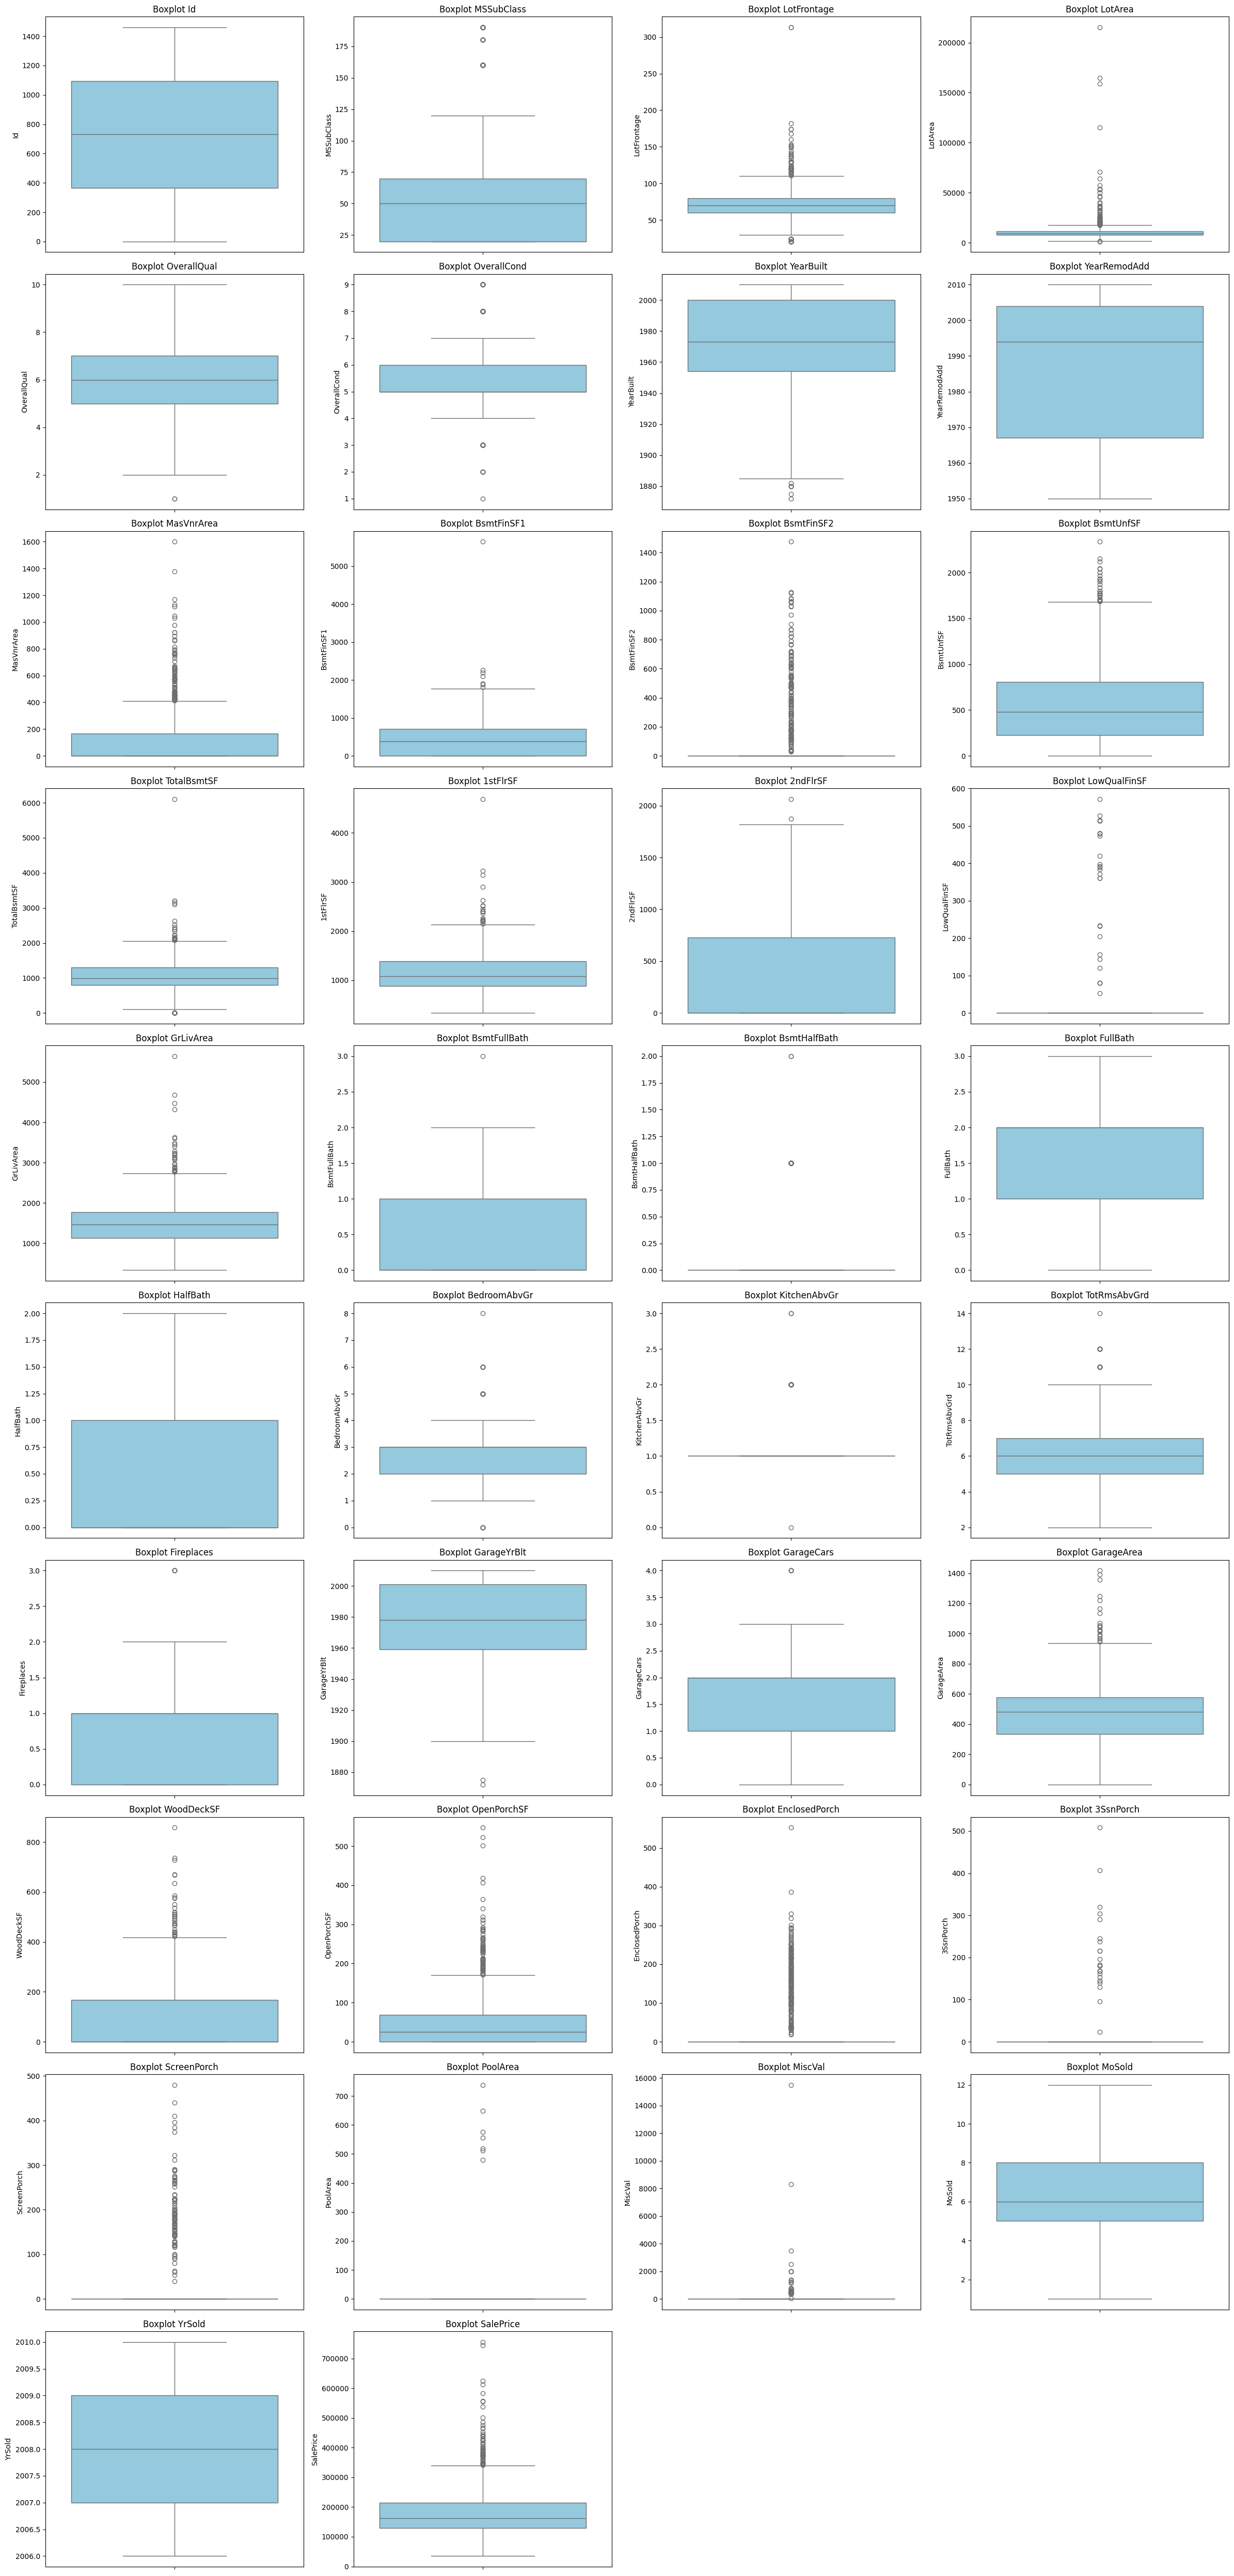

In [18]:
plt.figure(figsize=(24, 50))
for i, col in enumerate(kolom_numerik):
  if col in df.columns:
    plt.subplot(10, 4, i + 1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot {col}')
    plt.tight_layout()
plt.show()

In [19]:
X_num = df.select_dtypes(include=[np.number])

Q1 = X_num.quantile(0.25)
Q3 = X_num.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound = lower_bound.clip(lower=0)

print("Batas capping seluruh fitur numerik:")
display(pd.DataFrame({"lower": lower_bound, "upper": upper_bound}))

df[X_num.columns] = X_num.clip(lower=lower_bound, upper=upper_bound, axis=1)

Batas capping seluruh fitur numerik:


,lower,upper
Id,0.000,2189.500
MSSubClass,0.000,145.000
LotFrontage,30.000,110.000
LotArea,1481.500,17673.500
OverallQual,2.000,10.000
OverallCond,3.500,7.500
YearBuilt,1885.000,2069.000
YearRemodAdd,1911.500,2059.500
MasVnrArea,0.000,410.625
BsmtFinSF1,0.000,1780.625


# **Transformasi Data**

In [20]:
fitur_numerik = df.select_dtypes(include=[np.number]).columns.drop(['Id', 'SalePrice'])

scaler = StandardScaler()
df[fitur_numerik] = scaler.fit_transform(df[fitur_numerik])

fitur_kategori = df.select_dtypes(include=['object']).columns

df_encoded = pd.get_dummies(df, columns=fitur_kategori)
df = df_encoded.copy()

# **Reduksi Dimensi**

In [29]:
corr_matrix = df.corr().abs()

upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

threshold = 0.85
to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > threshold) and col != 'SalePrice']

print(f"Fitur yang dihapus:")
print(to_drop)

df_reduced = df.drop(columns=to_drop)
print(f"Jumlah kolom setelah eliminasi fitur: {df_reduced.shape[1]}")


X = df_reduced.drop(columns=['SalePrice', 'Id'])
y = df_reduced['SalePrice'] if 'SalePrice' in df_reduced.columns else None

pca = PCA(n_components=2)

data = df_reduced.drop(["Id", "SalePrice"], axis=1, errors='ignore')
label = df_reduced["SalePrice"]

principal_components = pca.fit_transform(data)

principal_components_df = pd.DataFrame(data=principal_components, columns=["PC1", "PC2"])
principal_components_df["label"] = label.values

principal_components_df.head()

Fitur yang dihapus:
['GarageArea', 'Street_Pave', 'LotShape_Reg', 'Utilities_NoSeWa', 'LandSlope_Mod', 'Neighborhood_Somerst', 'RoofStyle_Hip', 'Exterior2nd_CBlock', 'Exterior2nd_CmentBd', 'Exterior2nd_HdBoard', 'Exterior2nd_MetalSd', 'Exterior2nd_VinylSd', 'Exterior2nd_Wd Sdng', 'ExterQual_TA', 'ExterCond_TA', 'BsmtCond_None', 'BsmtExposure_None', 'BsmtFinType1_None', 'BsmtFinType2_None', 'CentralAir_Y', 'Electrical_SBrkr', 'FireplaceQu_None', 'GarageFinish_None', 'GarageQual_None', 'GarageCond_None', 'PavedDrive_Y', 'SaleCondition_Partial']
Jumlah kolom setelah eliminasi fitur: 256


,PC1,PC2,label
0,2.087708,0.637300,208500.0
1,0.023068,-1.451938,181500.0
2,2.385372,0.492501,223500.0
3,-0.553053,1.203317,140000.0
4,5.011049,1.419678,250000.0


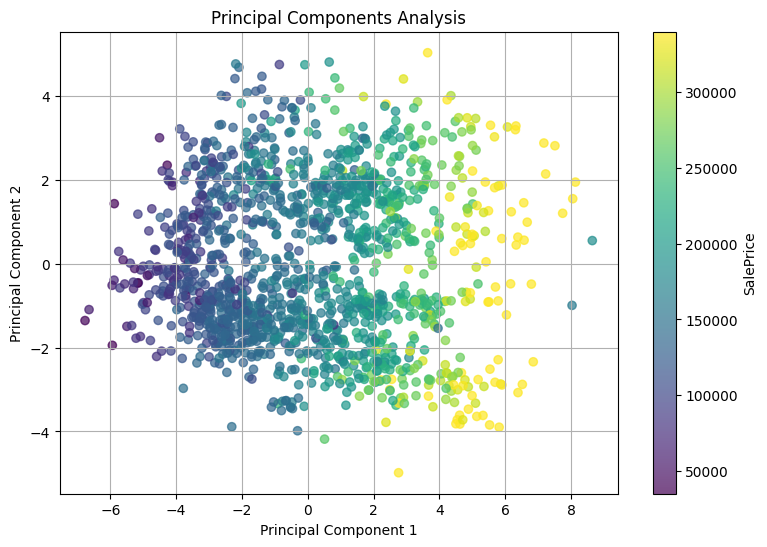

In [30]:
plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    principal_components_df['PC1'],
    principal_components_df['PC2'],
    c=principal_components_df['label'],
    cmap='viridis',
    alpha=0.7
)

plt.colorbar(scatter, label='SalePrice')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Principal Components Analysis')
plt.grid(True)
plt.show()

In [28]:
file_name = '5054251004_Muhammad Azka Ananta Khairon_Tugas_Praproses_Data.csv'
df_reduced.to_csv(file_name, index=False)